# HR Attrition Prediction (Classification)



In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from imblearn.over_sampling import SMOTE
from scipy.stats import randint

sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
RANDOM_STATE = 42


## 1. Load the dataset

Upload **HR-Employee-Attrition.csv** when prompted in Colab.


In [ ]:
uploaded = files.upload()  # Choose HR-Employee-Attrition.csv
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)
df.head()


Saving HR-Employee-Attrition.csv to HR-Employee-Attrition.csv


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## 2. Check dataset structure

In [ ]:
print('Shape:', df.shape)
print('\nColumns:')
print(df.columns.tolist())

print('\nData types:')
print(df.dtypes)

print('\nSummary statistics:')
display(df.describe(include='all').T)


Shape: (1470, 35)

Columns:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Data types:
Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber           

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,1470.0,NaN,NaN,NaN,36.92381,9.135373,18.0,30.0,36.0,43.0,60.0
Attrition,1470,2,No,1233,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BusinessTravel,1470,3,Travel_Rarely,1043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DailyRate,1470.0,NaN,NaN,NaN,802.485714,403.5091,102.0,465.0,802.0,1157.0,1499.0
Department,1470,3,Research & Development,961,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DistanceFromHome,1470.0,NaN,NaN,NaN,9.192517,8.106864,1.0,2.0,7.0,14.0,29.0
Education,1470.0,NaN,NaN,NaN,2.912925,1.024165,1.0,2.0,3.0,4.0,5.0
EducationField,1470,6,Life Sciences,606,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmployeeCount,1470.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
EmployeeNumber,1470.0,NaN,NaN,NaN,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0


In [ ]:
print('Missing values per column:')
display(df.isnull().sum().sort_values(ascending=False).to_frame('missing_count').head(10))

print('\nTotal missing values:', df.isnull().sum().sum())
print('Duplicate rows:', df.duplicated().sum())

print('\nTarget distribution:')
display(df['Attrition'].value_counts())
display((df['Attrition'].value_counts(normalize=True) * 100).round(2).astype(str) + '%')


Missing values per column:


,missing_count
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0



Total missing values: 0
Duplicate rows: 0

Target distribution:


,count
Attrition,
No,1233
Yes,237


,proportion
Attrition,
No,83.88%
Yes,16.12%


## 3. Basic cleaning decisions

This dataset usually has:
- no missing values
- no duplicate rows
- some constant columns that do not help prediction

We will identify and remove:
- constant columns
- employee identifier column


In [ ]:
constant_cols = [col for col in df.columns if df[col].nunique() == 1]
constant_cols


['EmployeeCount', 'Over18', 'StandardHours']

In [ ]:
drop_cols = constant_cols + ['EmployeeNumber']
print('Columns dropped:', drop_cols)

data = df.drop(columns=drop_cols).copy()
data.head()


Columns dropped: ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


## 4. Exploratory Data Analysis (EDA)

In [ ]:
numerical_cols = data.select_dtypes(include=np.number).columns.tolist()
categorical_cols = [col for col in data.select_dtypes(include='object').columns if col != 'Attrition']

print('Numerical columns:', numerical_cols)
print('\nCategorical columns:', categorical_cols)


Numerical columns: ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Categorical columns: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


### 4.1 Univariate analysis – numerical features

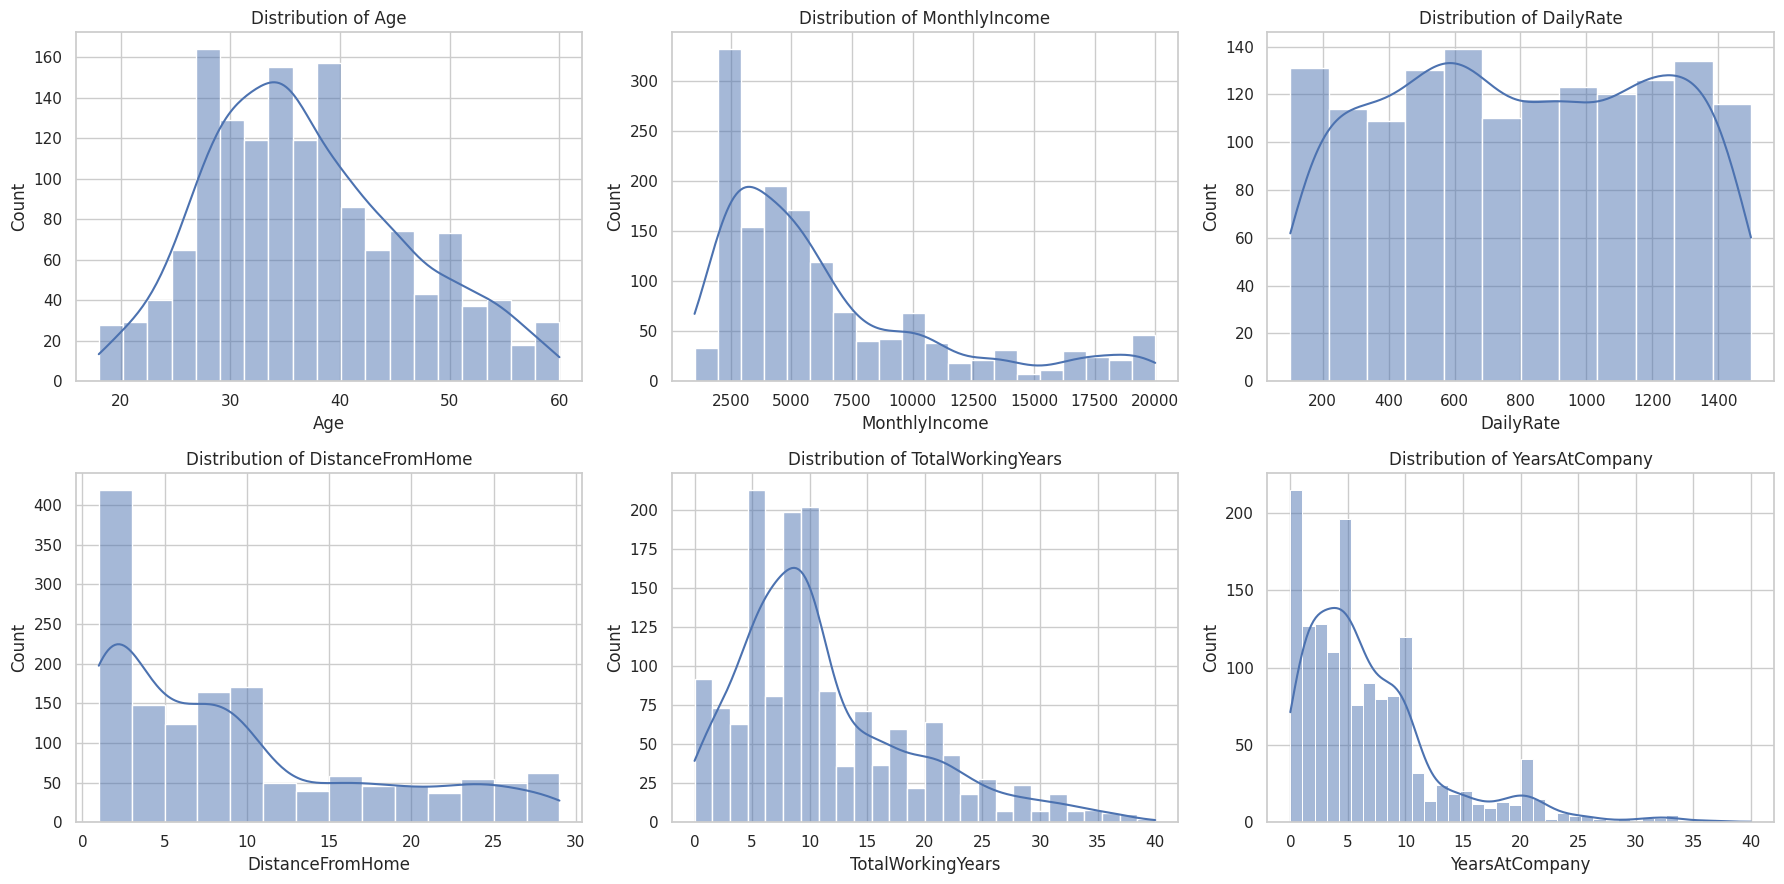

In [ ]:
sample_num_cols = ['Age', 'MonthlyIncome', 'DailyRate', 'DistanceFromHome', 'TotalWorkingYears', 'YearsAtCompany']

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(sample_num_cols):
    sns.histplot(data[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()


### 4.2 Univariate analysis – categorical features

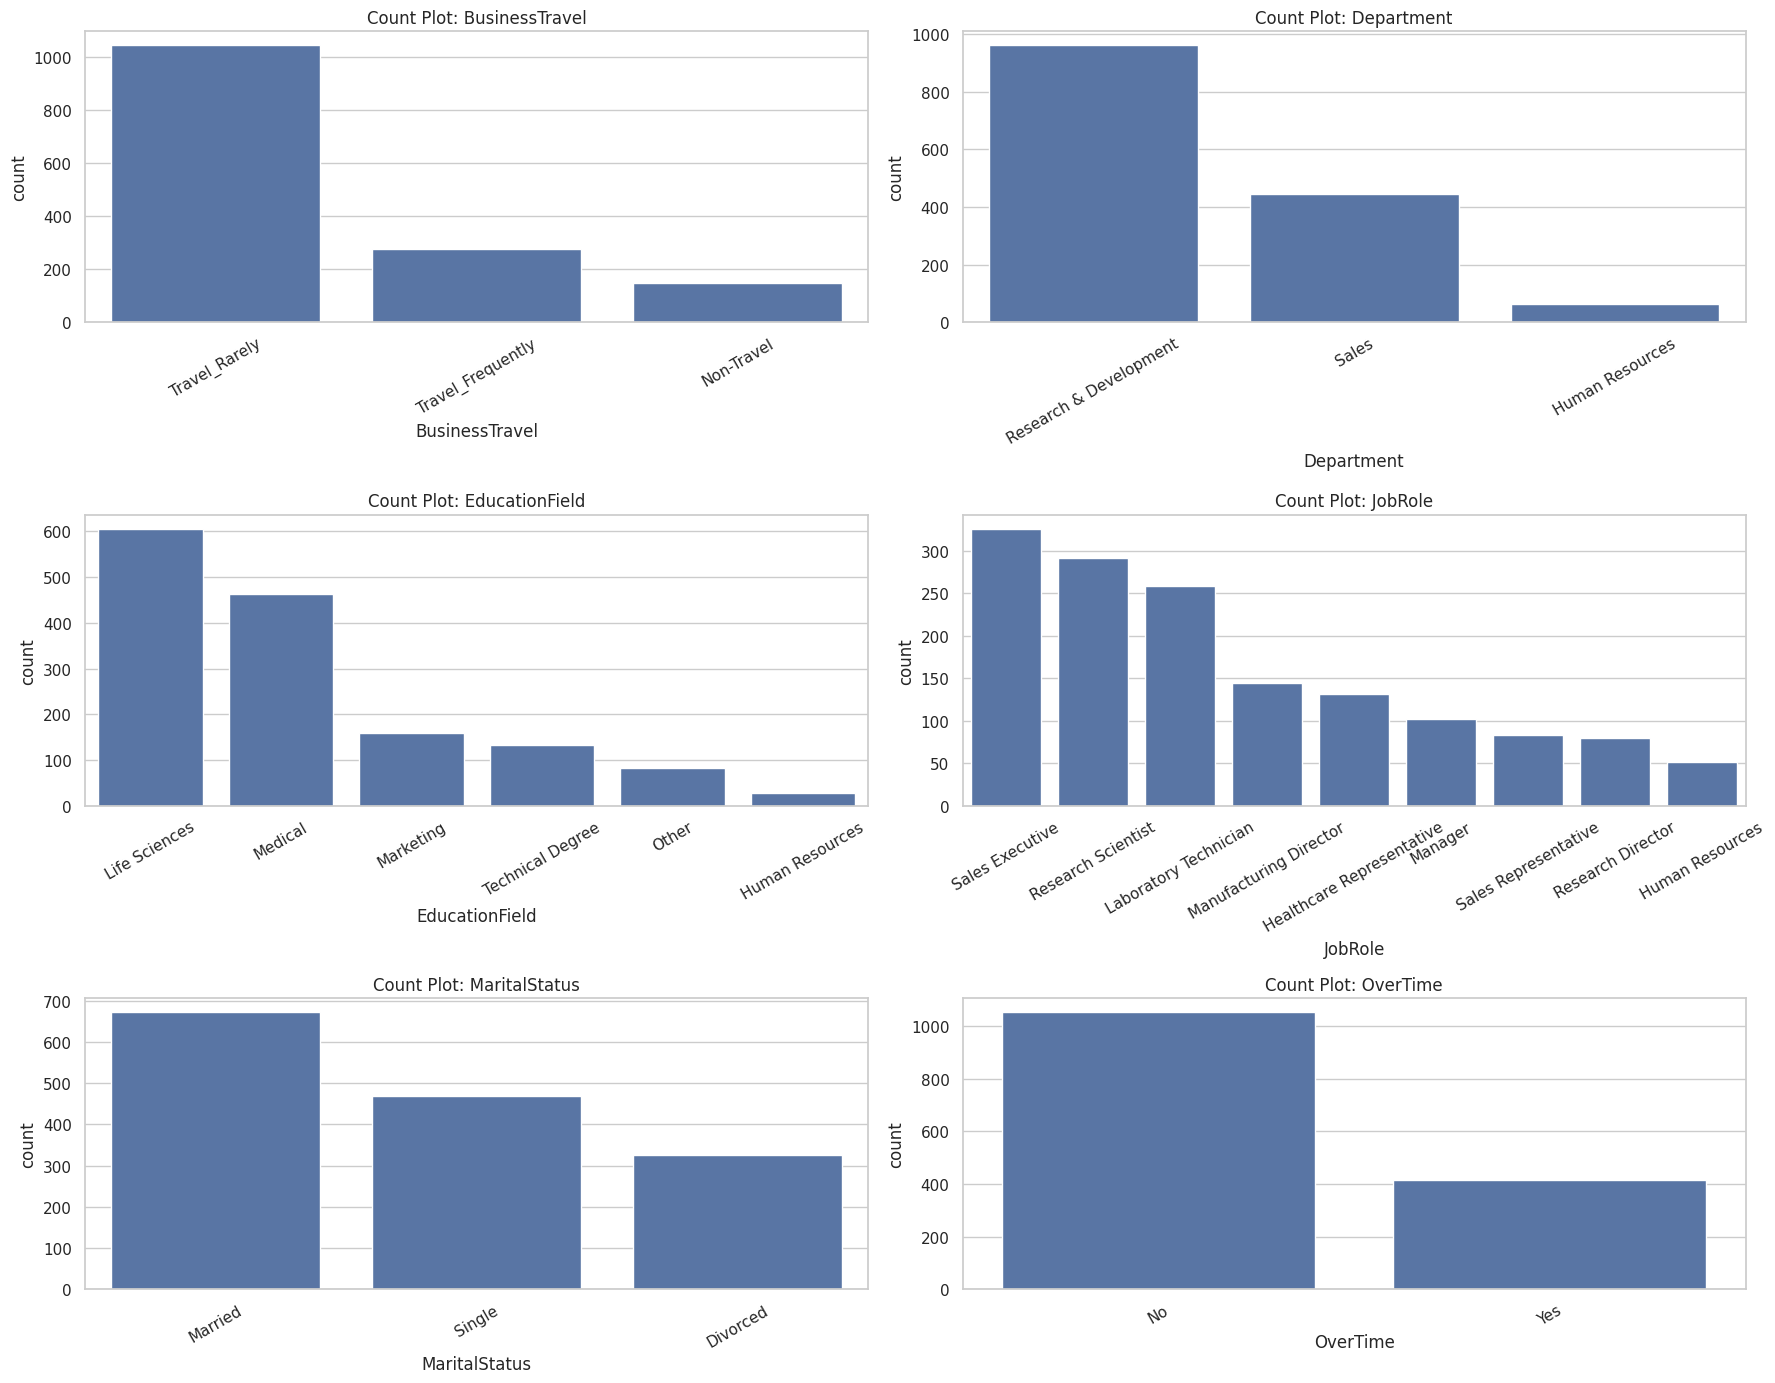

In [ ]:
sample_cat_cols = ['BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus', 'OverTime']

fig, axes = plt.subplots(3, 2, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(sample_cat_cols):
    sns.countplot(data=data, x=col, order=data[col].value_counts().index, ax=axes[i])
    axes[i].set_title(f'Count Plot: {col}')
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


### 4.3 Bivariate analysis – Attrition vs categorical features

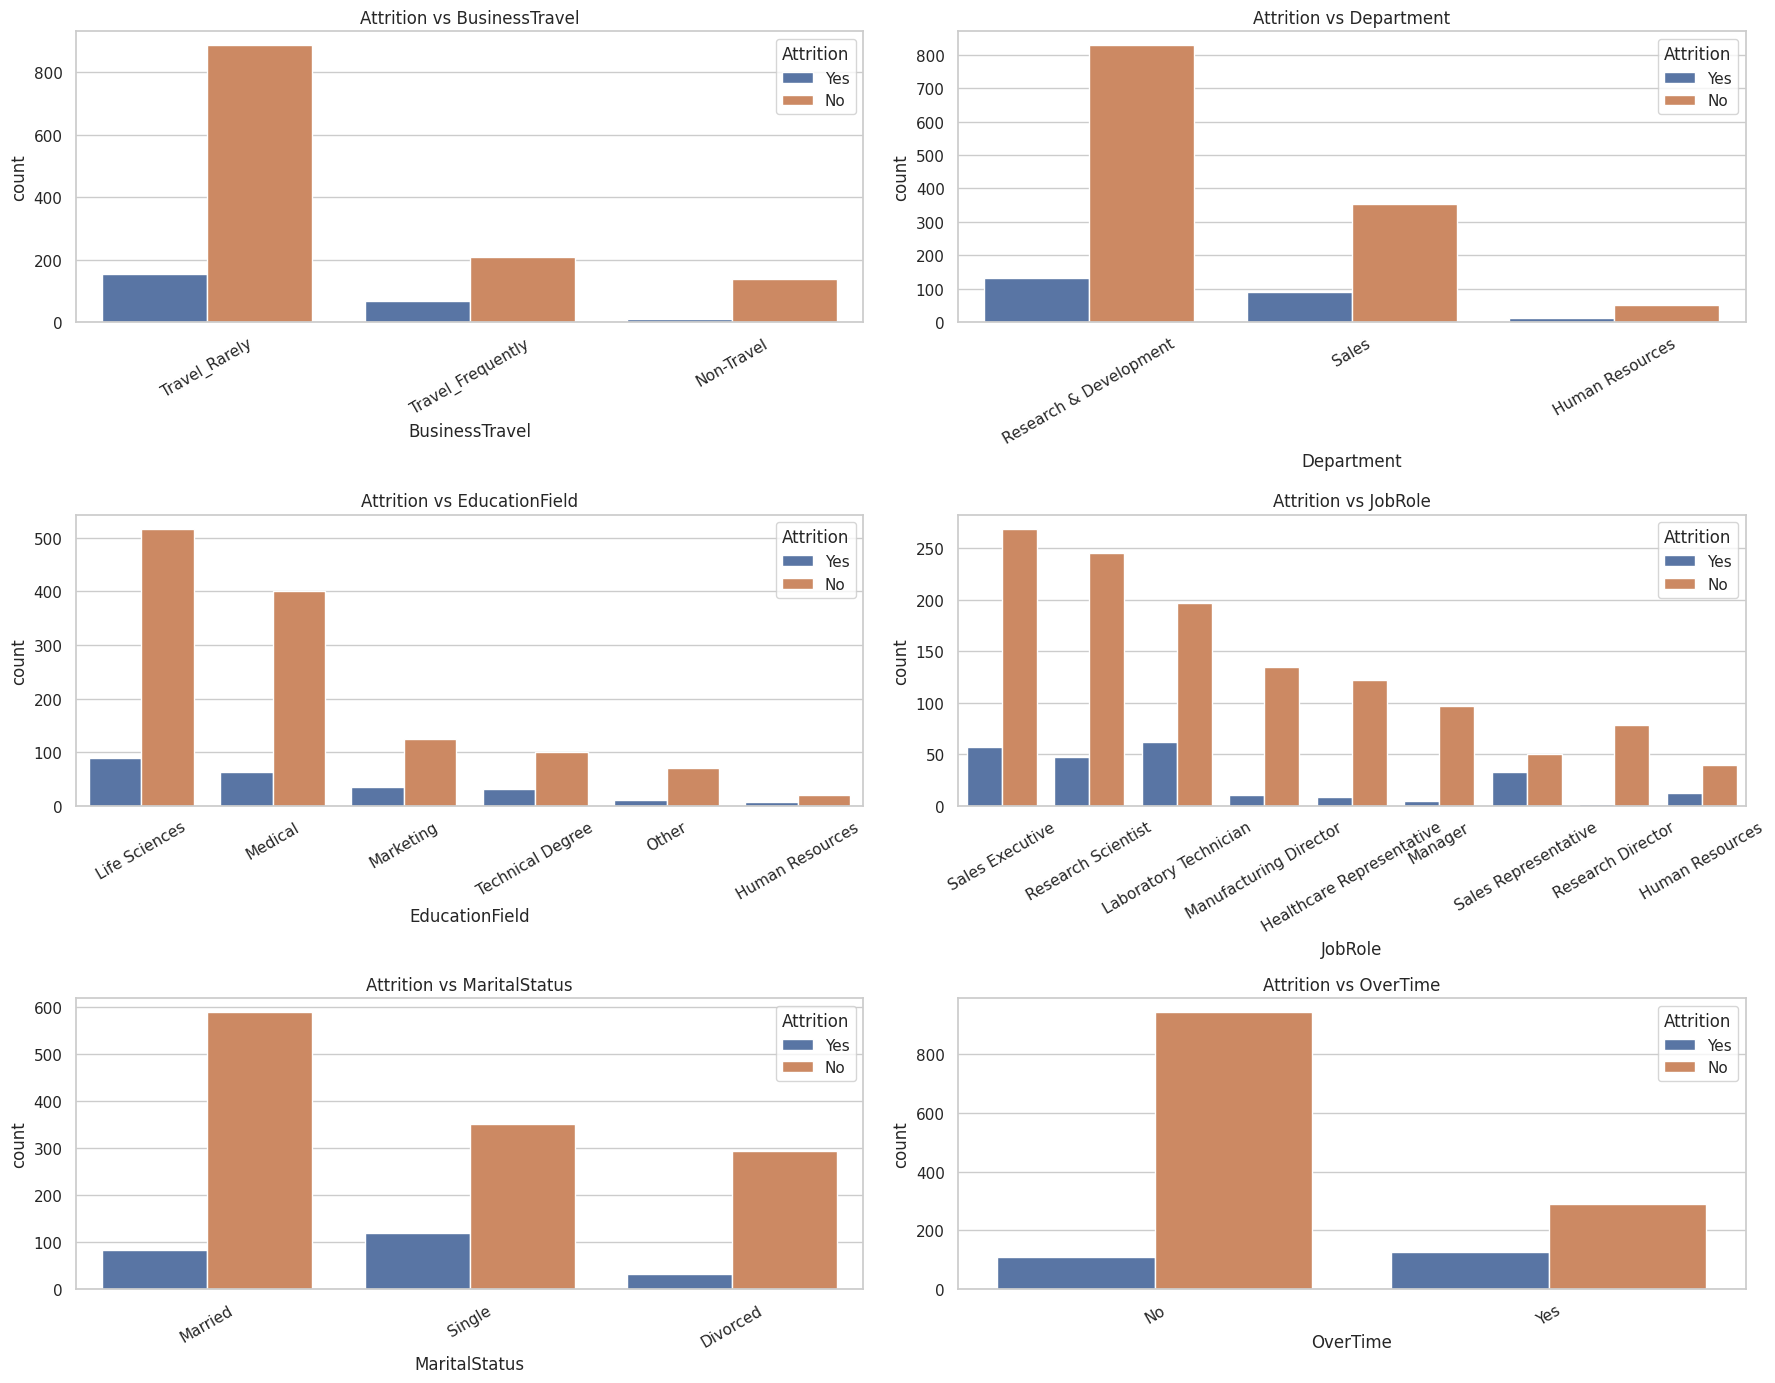

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(sample_cat_cols):
    sns.countplot(data=data, x=col, hue='Attrition', order=data[col].value_counts().index, ax=axes[i])
    axes[i].set_title(f'Attrition vs {col}')
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


### 4.4 Bivariate analysis – Attrition vs numerical features

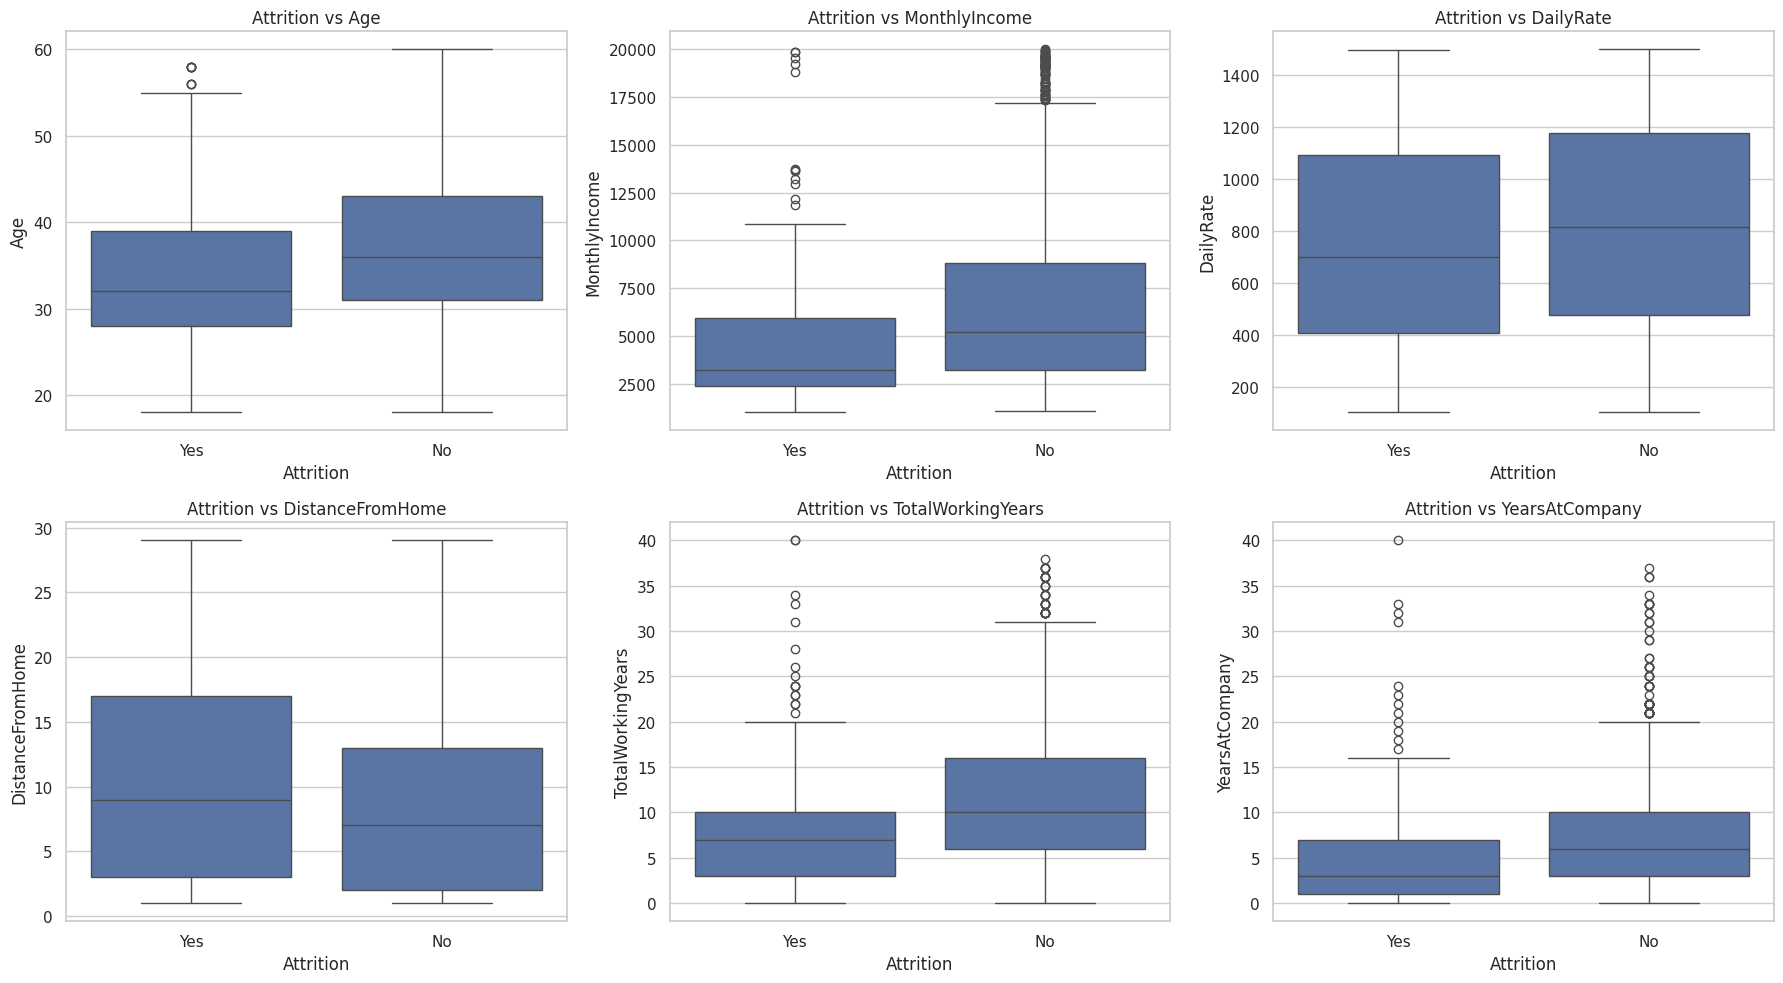

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(sample_num_cols):
    sns.boxplot(data=data, x='Attrition', y=col, ax=axes[i])
    axes[i].set_title(f'Attrition vs {col}')

plt.tight_layout()
plt.show()


### 4.5 Correlation heatmap

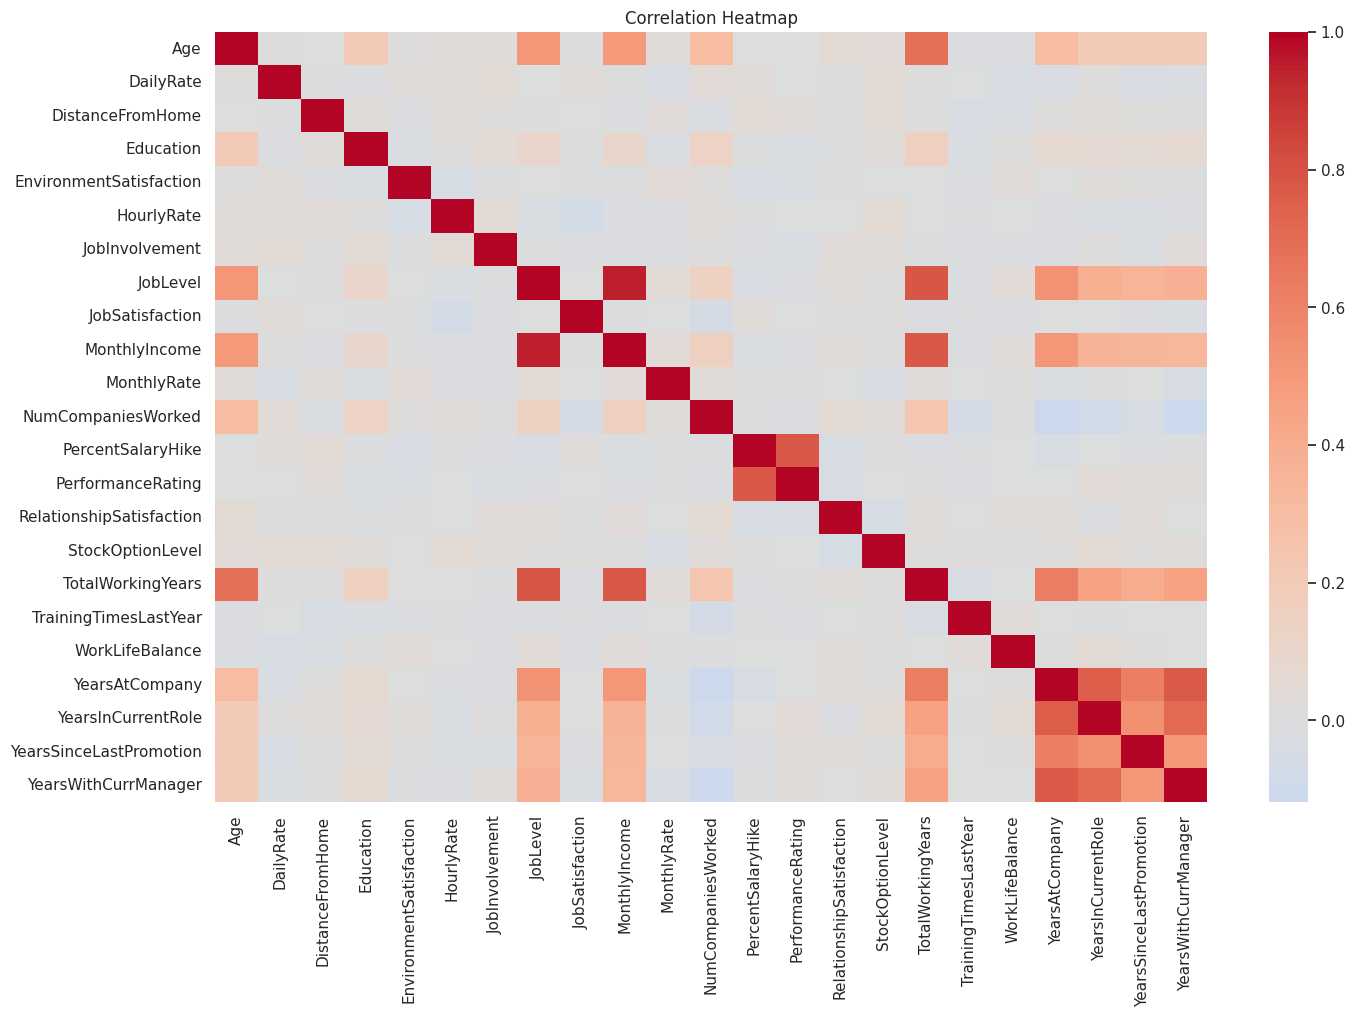

In [ ]:
plt.figure(figsize=(16, 10))
corr = data.select_dtypes(include=np.number).corr()
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()


## 5. Detect and handle outliers

We will use an **IQR-based capping transformer** for numerical columns.  
This avoids dropping rows and is safer than hard deletion for a business dataset.


In [ ]:
class IQRCapper(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        X = pd.DataFrame(X).copy()
        self.lower_bounds_ = {}
        self.upper_bounds_ = {}
        for col in X.columns:
            q1 = X[col].quantile(0.25)
            q3 = X[col].quantile(0.75)
            iqr = q3 - q1
            self.lower_bounds_[col] = q1 - 1.5 * iqr
            self.upper_bounds_[col] = q3 + 1.5 * iqr
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        for col in X.columns:
            X[col] = X[col].clip(self.lower_bounds_[col], self.upper_bounds_[col])
        return X.values


## 6. Separate features and target

In [ ]:
X = data.drop(columns='Attrition')
y = data['Attrition'].map({'No': 0, 'Yes': 1})

cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(exclude='object').columns.tolist()

print('Target classes:')
print(y.value_counts())


Target classes:
Attrition
0    1233
1     237
Name: count, dtype: int64


## 7. Train-test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print('Train shape:', X_train.shape)
print('Test shape :', X_test.shape)


Train shape: (1176, 30)
Test shape : (294, 30)


## 8. Preprocessing pipelines

- numerical: imputation -> outlier capping -> scaling (for LR and KNN)
- categorical: imputation -> one-hot encoding
- SMOTE is applied **after preprocessing** inside the pipeline


In [ ]:
numeric_scaled = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('capper', IQRCapper()),
    ('scaler', StandardScaler())
])

numeric_unscaled = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('capper', IQRCapper())
])

categorical_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor_scaled = ColumnTransformer(transformers=[
    ('num', numeric_scaled, num_cols),
    ('cat', categorical_pipe, cat_cols)
])

preprocessor_unscaled = ColumnTransformer(transformers=[
    ('num', numeric_unscaled, num_cols),
    ('cat', categorical_pipe, cat_cols)
])


## 9. Train classification models

In [ ]:
models = {
    'Logistic Regression': (
        preprocessor_scaled,
        LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE)
    ),
    'Decision Tree': (
        preprocessor_unscaled,
        DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight='balanced')
    ),
    'Random Forest': (
        preprocessor_unscaled,
        RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced')
    ),
    'KNN': (
        preprocessor_scaled,
        KNeighborsClassifier()
    )
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []
fitted_models = {}

for name, (prep, model) in models.items():
    pipe = ImbPipeline(steps=[
        ('prep', prep),
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('model', model)
    ])

    pipe.fit(X_train, y_train)
    fitted_models[name] = pipe

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    cv_f1 = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1').mean()

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba),
        'CV F1 (5-fold)': cv_f1
    })

results_df = pd.DataFrame(results).sort_values(by='F1 Score', ascending=False)
display(results_df.round(4))


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,CV F1 (5-fold)
0,Logistic Regression,0.7755,0.3827,0.6596,0.4844,0.7878,0.5089
2,Random Forest,0.8605,0.6667,0.2553,0.3692,0.7895,0.3986
1,Decision Tree,0.7891,0.3469,0.3617,0.3542,0.6161,0.3310
3,KNN,0.5680,0.2101,0.6170,0.3135,0.6149,0.3754


## 10. Confusion matrices for baseline models

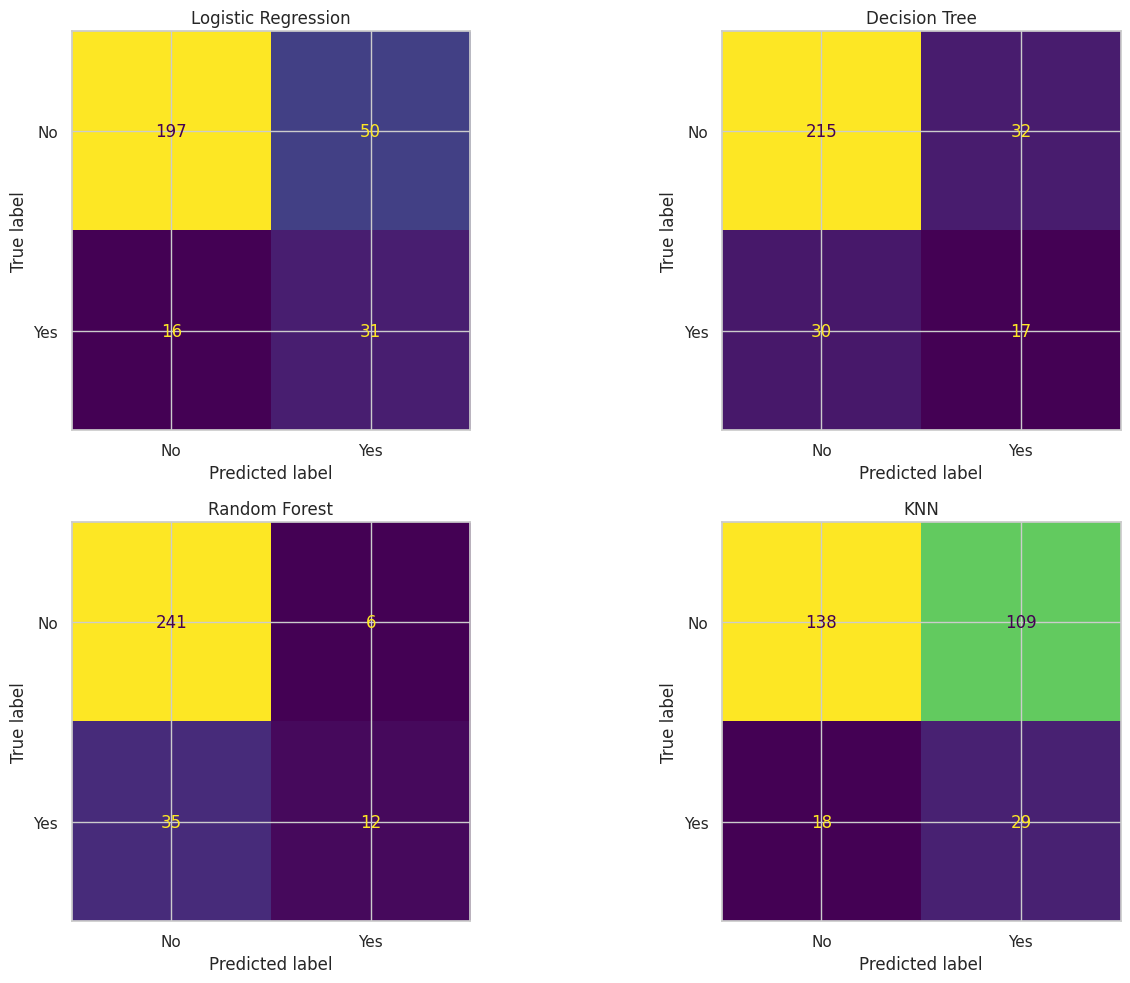

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (name, model) in zip(axes, fitted_models.items()):
    preds = model.predict(X_test)
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()


## 11. Hyperparameter tuning

We will tune:
- Logistic Regression using **GridSearchCV**
- Random Forest using **RandomizedSearchCV**


In [ ]:
log_pipe = ImbPipeline(steps=[
    ('prep', preprocessor_scaled),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('model', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
])

log_grid = {
    'model__C': [0.1, 1, 3, 10],
    'model__solver': ['liblinear'],
    'model__class_weight': [None, 'balanced']
}

log_search = GridSearchCV(
    estimator=log_pipe,
    param_grid=log_grid,
    scoring='f1',
    cv=3,
    n_jobs=-1
)

log_search.fit(X_train, y_train)

print('Best Logistic Regression Params:', log_search.best_params_)
print('Best CV F1:', round(log_search.best_score_, 4))


Best Logistic Regression Params: {'model__C': 0.1, 'model__class_weight': None, 'model__solver': 'liblinear'}
Best CV F1: 0.5217


In [ ]:
rf_pipe = ImbPipeline(steps=[
    ('prep', preprocessor_unscaled),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('model', RandomForestClassifier(random_state=RANDOM_STATE))
])

rf_dist = {
    'model__n_estimators': randint(150, 401),
    'model__max_depth': [None, 5, 8, 12, 16],
    'model__min_samples_split': randint(2, 12),
    'model__min_samples_leaf': randint(1, 6),
    'model__max_features': ['sqrt', 'log2', None],
    'model__class_weight': [None, 'balanced', 'balanced_subsample']
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipe,
    param_distributions=rf_dist,
    n_iter=8,
    scoring='f1',
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

print('Best Random Forest Params:', rf_search.best_params_)
print('Best CV F1:', round(rf_search.best_score_, 4))


Best Random Forest Params: {'model__class_weight': 'balanced', 'model__max_depth': 5, 'model__max_features': 'log2', 'model__min_samples_leaf': 1, 'model__min_samples_split': 11, 'model__n_estimators': 202}
Best CV F1: 0.4754


## 12. Evaluate tuned models


Tuned Logistic Regression
-------------------------
Accuracy      0.79932
Precision       0.425
Recall       0.723404
F1 Score     0.535433
ROC-AUC      0.802481
dtype: object

Classification Report:
              precision    recall  f1-score   support

          No       0.94      0.81      0.87       247
         Yes       0.42      0.72      0.54        47

    accuracy                           0.80       294
   macro avg       0.68      0.77      0.70       294
weighted avg       0.86      0.80      0.82       294



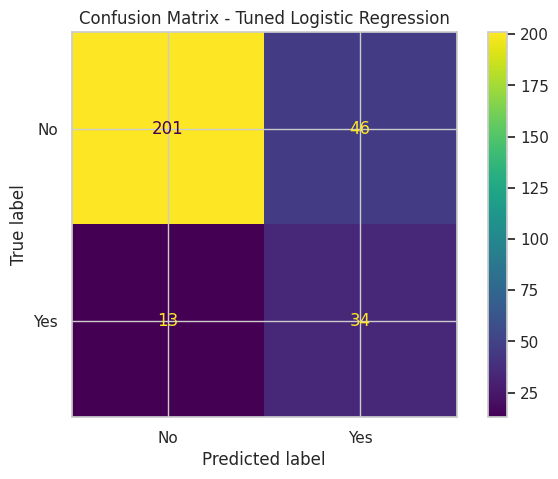


Tuned Random Forest
-------------------
Accuracy     0.846939
Precision    0.533333
Recall       0.340426
F1 Score     0.415584
ROC-AUC      0.811612
dtype: object

Classification Report:
              precision    recall  f1-score   support

          No       0.88      0.94      0.91       247
         Yes       0.53      0.34      0.42        47

    accuracy                           0.85       294
   macro avg       0.71      0.64      0.66       294
weighted avg       0.83      0.85      0.83       294



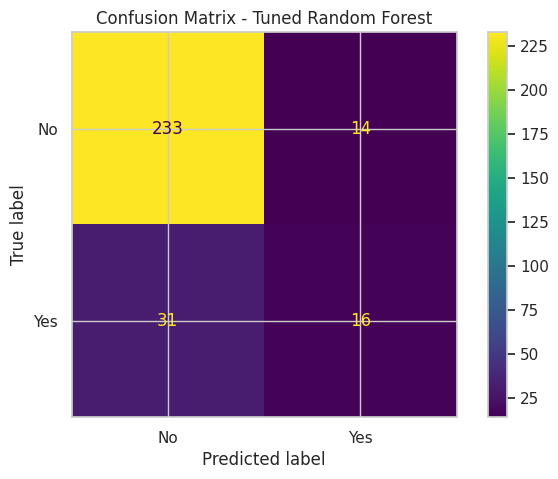

In [ ]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    metrics = {
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    }

    print(f'\n{name}')
    print('-' * len(name))
    print(pd.Series(metrics).drop('Model'))
    print('\nClassification Report:')
    print(classification_report(y_test, y_pred, target_names=['No', 'Yes']))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])
    disp.plot()
    plt.title(f'Confusion Matrix - {name}')
    plt.show()

    return metrics

tuned_log_metrics = evaluate_model('Tuned Logistic Regression', log_search.best_estimator_, X_test, y_test)
tuned_rf_metrics = evaluate_model('Tuned Random Forest', rf_search.best_estimator_, X_test, y_test)


In [ ]:
comparison_all = pd.concat([
    results_df,
    pd.DataFrame([tuned_log_metrics, tuned_rf_metrics])
], ignore_index=True)

comparison_all = comparison_all.sort_values(by=['F1 Score', 'ROC-AUC'], ascending=False)
display(comparison_all.round(4))


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,CV F1 (5-fold)
4,Tuned Logistic Regression,0.7993,0.4250,0.7234,0.5354,0.8025,NaN
0,Logistic Regression,0.7755,0.3827,0.6596,0.4844,0.7878,0.5089
5,Tuned Random Forest,0.8469,0.5333,0.3404,0.4156,0.8116,NaN
1,Random Forest,0.8605,0.6667,0.2553,0.3692,0.7895,0.3986
2,Decision Tree,0.7891,0.3469,0.3617,0.3542,0.6161,0.3310
3,KNN,0.5680,0.2101,0.6170,0.3135,0.6149,0.3754


## 13. Select the best model

For attrition prediction, **Recall** and **F1 Score** are especially important:
- recall matters because missing an employee likely to leave can hurt the company
- F1 is useful because attrition data is imbalanced
- ROC-AUC helps measure ranking quality

So the best business-balanced model is the one with the strongest **F1 + Recall + solid ROC-AUC**.


In [ ]:
best_model = log_search.best_estimator_
print('Selected Best Model: Tuned Logistic Regression')


Selected Best Model: Tuned Logistic Regression


## 14. Key factors influencing attrition

For Logistic Regression, feature coefficients help explain the direction of influence.
Positive coefficient -> pushes prediction toward attrition.
Negative coefficient -> pushes prediction toward non-attrition.


In [ ]:
prep = best_model.named_steps['prep']
ohe = prep.named_transformers_['cat'].named_steps['onehot']
feature_names = num_cols + ohe.get_feature_names_out(cat_cols).tolist()

coefs = best_model.named_steps['model'].coef_[0]
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefs
})

top_positive = coef_df.sort_values('Coefficient', ascending=False).head(10)
top_negative = coef_df.sort_values('Coefficient', ascending=True).head(10)

print('Top features increasing attrition risk:')
display(top_positive)

print('Top features reducing attrition risk:')
display(top_negative)


Top features increasing attrition risk:


,Feature,Coefficient
39,JobRole_Laboratory Technician,0.845826
50,OverTime_Yes,0.722621
24,BusinessTravel_Travel_Frequently,0.644067
45,JobRole_Sales Representative,0.612883
11,NumCompaniesWorked,0.464236
21,YearsSinceLastPromotion,0.411728
48,MaritalStatus_Single,0.362993
34,EducationField_Technical Degree,0.290885
28,Department_Sales,0.287807
29,EducationField_Human Resources,0.276863


Top features reducing attrition risk:


,Feature,Coefficient
49,OverTime_No,-0.929461
23,BusinessTravel_Non-Travel,-0.809366
33,EducationField_Other,-0.597734
16,TotalWorkingYears,-0.577839
42,JobRole_Research Director,-0.523523
43,JobRole_Research Scientist,-0.464327
4,EnvironmentSatisfaction,-0.430253
8,JobSatisfaction,-0.426725
22,YearsWithCurrManager,-0.393683
46,MaritalStatus_Divorced,-0.387464


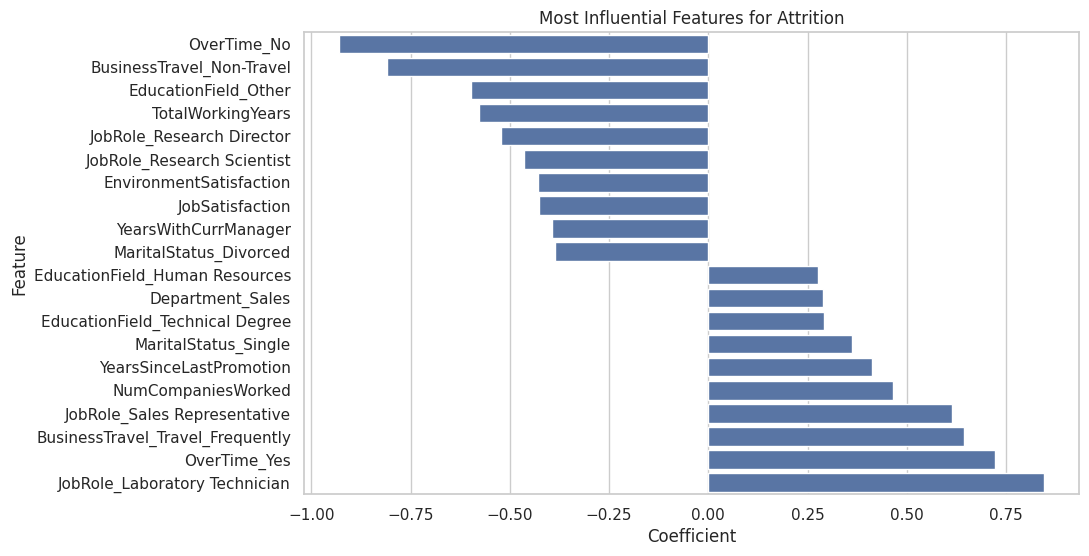

In [ ]:
plt.figure(figsize=(10, 6))
top_plot = pd.concat([top_positive, top_negative]).sort_values('Coefficient')
sns.barplot(data=top_plot, x='Coefficient', y='Feature')
plt.title('Most Influential Features for Attrition')
plt.show()


## 15. Final insights and business recommendations

### Likely attrition drivers
Typical patterns in this dataset often show higher attrition for employees with:
- overtime
- frequent travel
- some sales and laboratory roles
- longer delay since last promotion
- single marital status
- higher number of companies worked

### Lower attrition tends to be associated with
- better satisfaction measures
- higher age / more total work experience
- stronger manager tenure
- non-travel roles

### Business recommendations
1. Reduce overtime pressure where possible.
2. Track employees with high travel burden.
3. Create promotion and career-path reviews for at-risk employees.
4. Focus retention efforts on roles with consistently higher attrition.
5. Improve work-life balance and satisfaction interventions.
6. Build an early-warning retention dashboard using the selected model.


## 16. Conclusion

This notebook fully implements the HR Attrition classification task:
- complete data analysis
- preprocessing and outlier handling
- model comparison
- SMOTE for imbalance
- cross-validation
- hyperparameter tuning
- best-model selection
- business interpretation



## GitHub Link Placeholder

`https://github.com/anshul55555/HR_Attrition_Prediction.git`